In [1]:
import warnings
import numpy as np
import pandas as pd
import seaborn as sn
import matplotlib.pyplot as plt

# Patron data (linked with Hearing Australia audiometry)

The following cells compute descriptive statistics and basic plots regarding demographics for the patients that were linked with Hearing Australia and had a 3FAHL > 20.

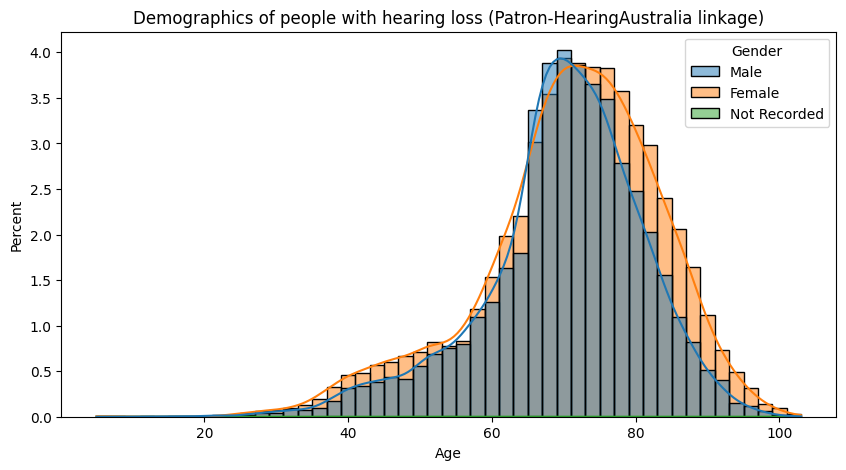

In [2]:
patron_hl_data = pd.read_csv('/Users/mcab8311/Documents/HEIDI/basic_demographics_Patron-HA-HL.csv')

plt.figure(figsize=(10, 5))
sn.histplot(data=patron_hl_data, x='Age', hue='Gender', kde=True, binwidth=2, stat='percent')
plt.title('Demographics of people with hearing loss (Patron-HearingAustralia linkage)')
patron_hl_data['Gender'] = patron_hl_data['Gender'].astype('category')

In [3]:
warnings.simplefilter(action='ignore', category=FutureWarning)
patron_hl_data.set_index('PUID').groupby('Gender').describe()

Age                                                      
                count       mean        std   min    25%   50%   75%    max
Gender                                                                     
Female        11962.0  70.750627  12.683306   5.0  64.00  72.0  79.0  103.0
Male           9946.0  69.692540  11.282290  12.0  65.00  71.0  77.0  102.0
Not Recorded      4.0  51.250000  11.500000  37.0  46.75  51.5  56.0   65.0

In [4]:
warnings.simplefilter(action='ignore', category=FutureWarning)
patron_hl_data.set_index('PUID').describe()

,Age
count,21913.000000
mean,70.267102
std,12.080851
min,5.000000
25%,65.000000
50%,71.000000
75%,78.000000
max,103.000000


In [5]:
warnings.simplefilter(action='ignore', category=FutureWarning)
patron_hl_data[patron_hl_data['Age'] >= 45].set_index('PUID').groupby('Gender').describe()

Age                                                     
                count       mean        std   min   25%   50%   75%    max
Gender                                                                    
Female        11421.0  72.279835  10.743595  45.0  66.0  73.0  80.0  103.0
Male           9590.0  70.851408   9.664058  45.0  66.0  71.0  77.0  102.0
Not Recorded      3.0  56.000000   7.937254  50.0  51.5  53.0  59.0   65.0

In [6]:
warnings.simplefilter(action='ignore', category=FutureWarning)
patron_hl_data[patron_hl_data['Age'] >= 45].set_index('PUID').describe()

,Age
count,21015.000000
mean,71.625886
std,10.290421
min,45.000000
25%,66.000000
50%,72.000000
75%,79.000000
max,103.000000


# Patron data (not linked)

# SpecSavers data

The following cells have some basic descriptive analytics on the Specsavers data

In [7]:
au_data = pd.read_csv('/Users/mcab8311/Documents/HEIDI/AU_screeners_data.csv')
nz_data = pd.read_csv('/Users/mcab8311/Documents/HEIDI/NZ_screeners_data.csv')

au_ages = au_data.assign(
    age=pd.to_numeric(au_data['testDateTime'].str[-4:]) - pd.to_numeric(au_data['birthday']).to_numpy()
)
nz_ages = nz_data.assign(
    age=pd.to_numeric(nz_data['testDateTime'].str[-4:]) - pd.to_numeric(nz_data['birthday']).to_numpy()
)

min_au = np.min(au_ages['age'])
max_au = np.max(au_ages['age'])
min_nz = np.min(nz_ages['age'])
max_nz = np.max(nz_ages['age'])

print(f'AU participants: {len(au_ages)} [{min_au} - {max_au}]')
print(f'NZ participants {len(nz_ages)} [{min_nz} - {max_nz}]')

print(f'All participants {len(au_ages) + len(nz_ages)}')

AU participants: 2213560 [0 - 124]
NZ participants 382344 [0.0 - 124.0]
All participants 2595904


## Australian participants

In [8]:
au_ages

,testDateTime,birthday,hlLeft.freq500,hlLeft.freq1000,hlLeft.freq2000,hlLeft.freq4000,hlRight.freq500,hlRight.freq1000,hlRight.freq2000,hlRight.freq4000,age
0,14-09-2023,1964,30,10,20,70,30,20,20,50,59
1,07-11-2022,1961,40,30,30,80,40,30,40,80,61
2,31-08-2023,1942,30,40,40,70,40,30,40,60,81
3,27-04-2023,1954,30,40,30,70,30,40,20,70,69
4,31-01-2024,1953,40,30,20,50,40,30,30,40,71
...,...,...,...,...,...,...,...,...,...,...,...
2213555,10-12-2020,1963,80,40,20,20,50,40,30,20,57
2213556,11-12-2020,1957,30,30,20,40,40,40,20,30,63
2213557,11-12-2020,1933,50,40,30,50,80,60,40,50,87
2213558,11-12-2020,1952,40,30,20,20,40,40,20,20,68


Text(0.5, 1.0, 'General demographics of SpecSavers participants (Australia)')

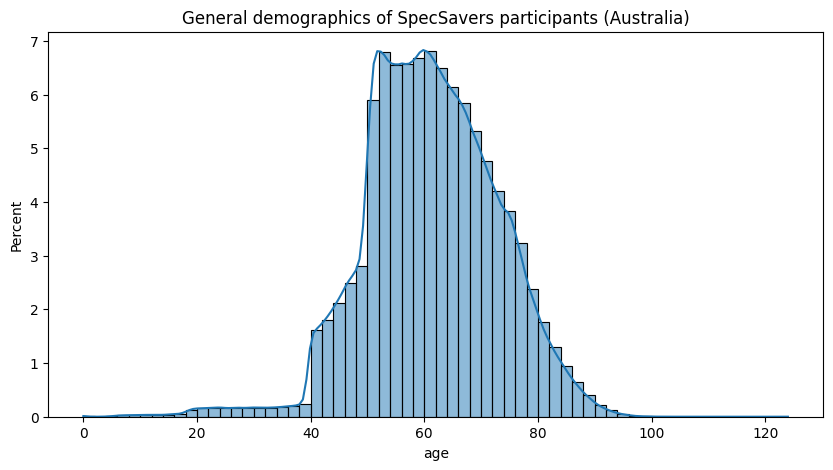

In [45]:
plt.figure(figsize=(10, 5))
sn.histplot(data=au_ages, x='age', kde=True, stat='percent', binwidth=2)
plt.title('General demographics of SpecSavers participants (Australia)')

In [41]:
au_fahl = au_ages.assign(
    fahl3Left=(
        (
            pd.to_numeric(au_ages['hlLeft.freq500']) +
            pd.to_numeric(au_ages['hlLeft.freq1000']) +
            pd.to_numeric(au_ages['hlLeft.freq2000'])
        ) / 3
    ).to_numpy()
)
au_fahl = au_fahl.assign(
    fahl3Right=(
        (
            pd.to_numeric(au_ages['hlRight.freq500']) +
            pd.to_numeric(au_ages['hlRight.freq1000']) +
            pd.to_numeric(au_ages['hlRight.freq2000'])
        ) / 3
    ).to_numpy()
)

spec_au_hl = au_fahl[(au_fahl['fahl3Right'] > 20) | (au_fahl['fahl3Left'] > 20)]

In [42]:
print('People with hearing loss {:5.2f}% (SpecSavers Australia)'.format(100 * len(spec_au_hl) / len(au_fahl)))

People with hearing loss 92.97% (SpecSavers Australia)


Text(0.5, 1.0, 'General demographics of SpecSavers participants (Australia) with 3FAHL > 20dB')

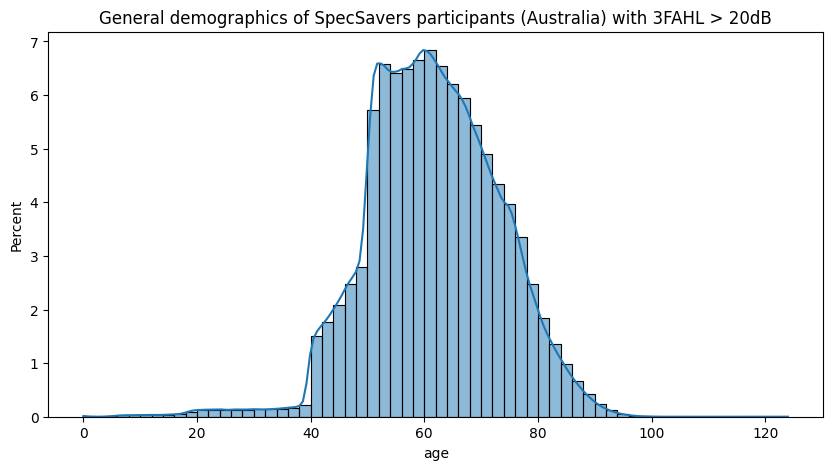

In [46]:
plt.figure(figsize=(10, 5))
sn.histplot(data=spec_au_hl, x='age', kde=True, stat='percent', binwidth=2)
plt.title('General demographics of SpecSavers participants (Australia) with 3FAHL > 20dB')

In [12]:
spec_demo = spec_au_hl.loc[:, 
    ~spec_au_hl.columns.str.contains('freq') &
    ~spec_au_hl.columns.str.contains('birthday') &
    ~spec_au_hl.columns.str.contains('Date')
]
filt_spec_demo = spec_demo[spec_demo['age'] > 45]

In [13]:
filt_spec_demo.describe()

,age,fahl3Left,fahl3Right
count,1.910926e+06,1.910926e+06,1.910926e+06
mean,6.318920e+01,3.187189e+01,3.364047e+01
std,9.842331e+00,9.623001e+00,1.024150e+01
min,4.600000e+01,1.000000e+01,1.000000e+01
25%,5.500000e+01,2.666667e+01,2.666667e+01
50%,6.200000e+01,3.000000e+01,3.000000e+01
75%,7.000000e+01,3.333333e+01,3.666667e+01
max,1.240000e+02,8.000000e+01,8.000000e+01


In [29]:
range_spec_demo = filt_spec_demo.assign(
    age=filt_spec_demo['age'] // 10 * 10
)
range_spec_demo.groupby('age').describe()

fahl3Left                                                               \
        count       mean        std   min        25%        50%        75%   
age                                                                          
40   108123.0  29.565680   7.092583  10.0  26.666667  30.000000  33.333333   
50   656115.0  29.728396   7.762970  10.0  26.666667  30.000000  33.333333   
60   637314.0  31.236952   8.759917  10.0  26.666667  30.000000  33.333333   
70   391545.0  34.336615  10.657987  10.0  26.666667  33.333333  36.666667   
80   108594.0  40.526057  13.405378  10.0  30.000000  36.666667  46.666667   
90     9144.0  48.738699  15.013808  10.0  36.666667  46.666667  56.666667   
100      54.0  54.012346  20.077206  10.0  38.333333  53.333333  73.333333   
110       4.0  31.666667   3.333333  30.0  30.000000  30.000000  31.666667   
120      33.0  35.757576  19.225864  10.0  26.666667  30.000000  40.000000   

               fahl3Right                                              \
           max      count       mean        std        min        25%   
age                                                                     
40   80.000000   108123.0  30.856648   7.539510  10.000000  26.666667   
50   80.000000   656115.0  31.211861   8.239533  10.000000  26.666667   
60   80.000000   637314.0  32.979865   9.350039  10.000000  26.666667   
70   80.000000   391545.0  36.455554  11.268523  10.000000  30.000000   
80   80.000000   108594.0  43.264484  13.919897  10.000000  33.333333   
90   80.000000     9144.0  51.868256  14.901924  10.000000  40.000000   
100  80.000000       54.0  56.543210  16.772781  23.333333  43.333333   
110  36.666667        4.0  39.166667  11.979921  30.000000  32.500000   
120  80.000000       33.0  38.787879  16.474268  16.666667  26.666667   

                                      
           50%        75%        max  
age                                   
40   30.000000  33.333333  80.000000  
50   30.000000  33.333333  80.000000  
60   30.000000  36.666667  80.000000  
70   33.333333  40.000000  80.000000  
80   40.000000  50.000000  80.000000  
90   50.000000  60.000000  80.000000  
100  56.666667  72.500000  80.000000  
110  35.000000  41.666667  56.666667  
120  30.000000  53.333333  80.000000

Text(0.5, 1.0, '3FAHL right by age')

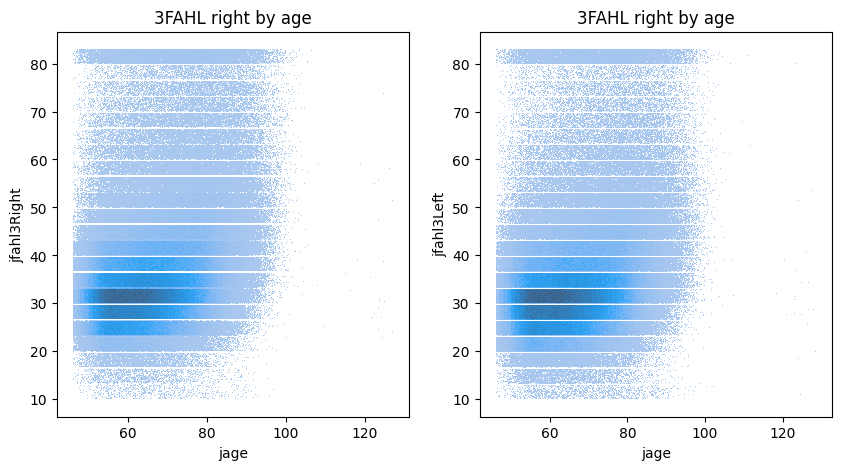

In [68]:
jitter_right = filt_spec_demo.assign(
    jfahl3Right=filt_spec_demo['fahl3Right'] + np.random.rand(len(filt_spec_demo)) * 3
)
jitter_right = jitter_right.assign(
    jage=filt_spec_demo['age'] + np.random.rand(len(filt_spec_demo)) * 5
)
jitter_left = filt_spec_demo.assign(
    jfahl3Left=filt_spec_demo['fahl3Left'] + np.random.rand(len(filt_spec_demo)) * 3
)
jitter_left = jitter_left.assign(
    jage=filt_spec_demo['age'] + np.random.rand(len(filt_spec_demo)) * 5
)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sn.histplot(data=jitter_right, x='jage', y='jfahl3Right')
plt.title('3FAHL right by age')
plt.subplot(1, 2, 2)
sn.histplot(data=jitter_left, x='jage', y='jfahl3Left')
plt.title('3FAHL right by age')

## New Zealand participants

In [49]:
nz_ages

,testDateTime,birthday,hlLeft.freq500,hlLeft.freq1000,hlLeft.freq2000,hlLeft.freq4000,hlRight.freq500,hlRight.freq1000,hlRight.freq2000,hlRight.freq4000,age
0,02-07-2021,1974,40,30,30.0,30,30,30,20.0,30,47.0
1,05-08-2022,1966,40,30,20.0,30,30,40,30.0,60,56.0
2,17-06-2021,1956,50,40,20.0,40,40,30,20.0,30,65.0
3,18-12-2021,1961,50,40,20.0,30,50,40,30.0,60,60.0
4,29-09-2022,1977,30,30,20.0,30,30,30,20.0,10,45.0
...,...,...,...,...,...,...,...,...,...,...,...
382339,01-11-2022,1953,30,20,20.0,20,30,20,10.0,10,69.0
382340,30-11-2021,1939,30,30,40.0,60,30,30,30.0,60,82.0
382341,03-03-2022,1950,30,30,30.0,30,50,40,40.0,30,72.0
382342,31-12-2020,1947,40,30,30.0,60,50,50,40.0,70,73.0


Text(0.5, 1.0, 'General demographics of SpecSavers participants (New Zealand)')

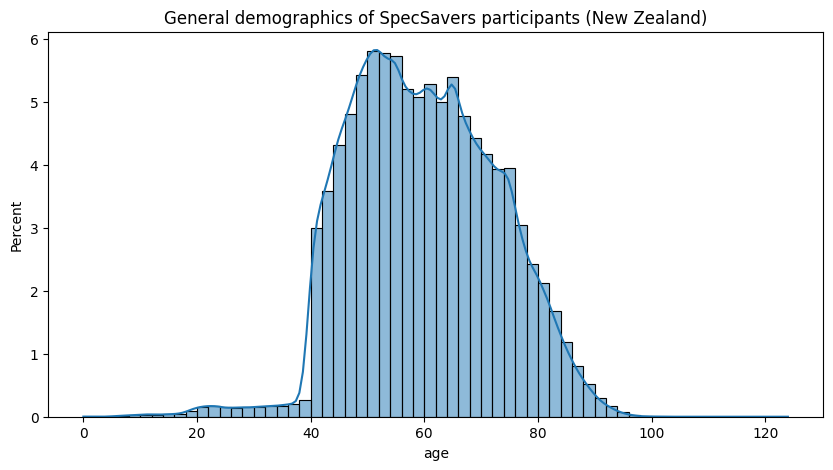

In [50]:
plt.figure(figsize=(10, 5))
sn.histplot(data=nz_ages, x='age', kde=True, stat='percent', binwidth=2)
plt.title('General demographics of SpecSavers participants (New Zealand)')

In [51]:
nz_fahl = nz_ages.assign(
    fahl3Left=(
        (
            pd.to_numeric(nz_ages['hlLeft.freq500']) +
            pd.to_numeric(nz_ages['hlLeft.freq1000']) +
            pd.to_numeric(nz_ages['hlLeft.freq2000'])
        ) / 3
    ).to_numpy()
)
nz_fahl = nz_fahl.assign(
    fahl3Right=(
        (
            pd.to_numeric(nz_ages['hlRight.freq500']) +
            pd.to_numeric(nz_ages['hlRight.freq1000']) +
            pd.to_numeric(nz_ages['hlRight.freq2000'])
        ) / 3
    ).to_numpy()
)

spec_nz_fahl = nz_fahl[(nz_fahl['fahl3Right'] > 20) | (nz_fahl['fahl3Left'] > 20)]

In [54]:
print('People with hearing loss {:5.2f}% (SpecSavers New Zealand)'.format(100 * len(spec_nz_fahl) / len(nz_fahl)))

People with hearing loss 90.88% (SpecSavers New Zealand)


Text(0.5, 1.0, 'General demographics of SpecSavers participants (New Zealand) with 3FAHL > 20dB')

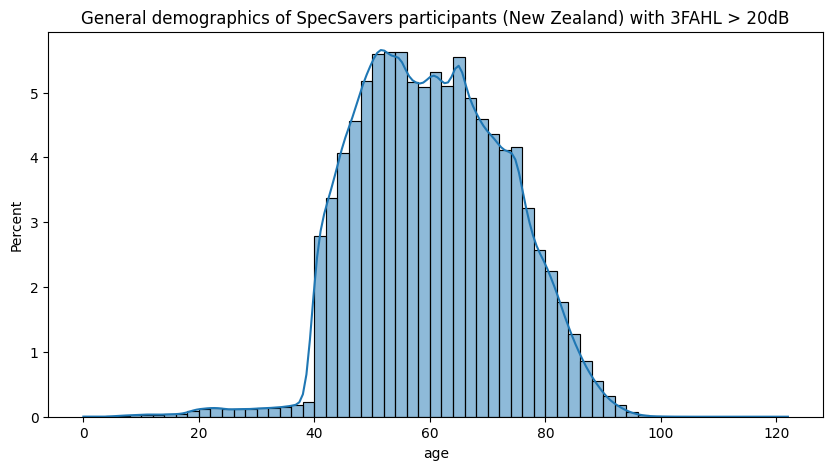

In [55]:
plt.figure(figsize=(10, 5))
sn.histplot(data=spec_nz_fahl, x='age', kde=True, stat='percent', binwidth=2)
plt.title('General demographics of SpecSavers participants (New Zealand) with 3FAHL > 20dB')

In [56]:
spec_nz_demo = spec_nz_fahl.loc[:, 
    ~spec_nz_fahl.columns.str.contains('freq') &
    ~spec_nz_fahl.columns.str.contains('birthday') &
    ~spec_nz_fahl.columns.str.contains('Date')
]
filt_spec_nz_demo = spec_nz_demo[spec_nz_demo['age'] > 45]

In [57]:
filt_spec_nz_demo.describe()

,age,fahl3Left,fahl3Right
count,305997.000000,305997.000000,305997.000000
mean,63.085230,31.946435,33.587094
std,10.900046,10.460617,10.992106
min,46.000000,10.000000,10.000000
25%,54.000000,26.666667,26.666667
50%,62.000000,30.000000,30.000000
75%,71.000000,36.666667,36.666667
max,122.000000,80.000000,80.000000


In [58]:
range_spec_nz_demo = filt_spec_nz_demo.assign(
    age=filt_spec_nz_demo['age'] // 10 * 10
)
range_spec_nz_demo.groupby('age').describe()

fahl3Left                                                         \
          count       mean        std        min        25%        50%   
age                                                                      
40.0    33842.0  28.869452   7.665514  10.000000  23.333333  26.666667   
50.0    94158.0  29.540666   8.194361  10.000000  23.333333  30.000000   
60.0    88529.0  31.202393   9.433606  10.000000  26.666667  30.000000   
70.0    64018.0  34.470878  11.463714  10.000000  26.666667  33.333333   
80.0    23360.0  40.526113  14.220173  10.000000  30.000000  36.666667   
90.0     2070.0  48.400966  16.096523  10.000000  36.666667  43.333333   
100.0      17.0  51.764706  22.426350  16.666667  36.666667  50.000000   
110.0       1.0  80.000000        NaN  80.000000  80.000000  80.000000   
120.0       2.0  55.000000  35.355339  30.000000  42.500000  55.000000   

                       fahl3Right                                              \
             75%   max      count       mean        std        min        25%   
age                                                                             
40.0   33.333333  80.0    33842.0  30.344148   8.219218  10.000000  26.666667   
50.0   33.333333  80.0    94158.0  30.961646   8.651308  10.000000  26.666667   
60.0   33.333333  80.0    88529.0  32.743470   9.902086  10.000000  26.666667   
70.0   40.000000  80.0    64018.0  36.340092  12.020169  10.000000  30.000000   
80.0   46.666667  80.0    23360.0  42.918950  14.502465  10.000000  33.333333   
90.0   56.666667  80.0     2070.0  51.473430  16.020592  10.000000  40.000000   
100.0  70.000000  80.0       17.0  51.176471  19.470104  23.333333  36.666667   
110.0  80.000000  80.0        1.0  80.000000        NaN  80.000000  80.000000   
120.0  67.500000  80.0        2.0  51.666667  40.069384  23.333333  37.500000   

                                   
             50%        75%   max  
age                                
40.0   30.000000  33.333333  80.0  
50.0   30.000000  33.333333  80.0  
60.0   30.000000  36.666667  80.0  
70.0   33.333333  40.000000  80.0  
80.0   40.000000  50.000000  80.0  
90.0   46.666667  63.333333  80.0  
100.0  46.666667  66.666667  80.0  
110.0  80.000000  80.000000  80.0  
120.0  51.666667  65.833333  80.0

Text(0.5, 1.0, '3FAHL right by age')

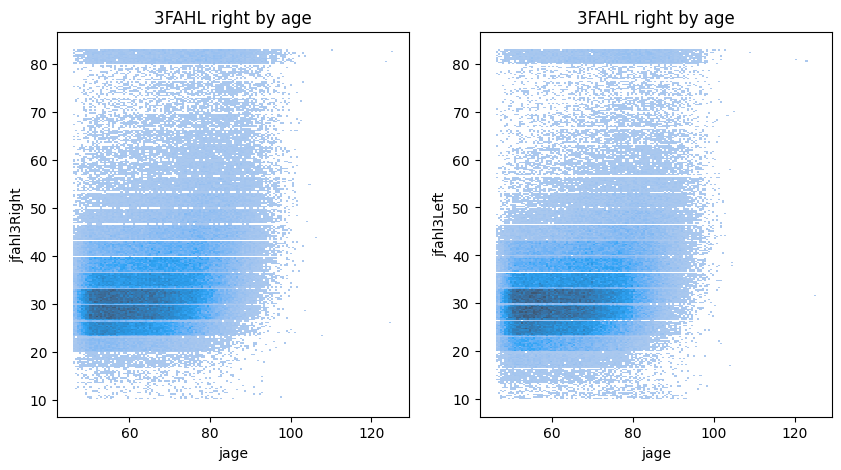

In [69]:
jitter_nz_right = filt_spec_nz_demo.assign(
    jfahl3Right=filt_spec_nz_demo['fahl3Right'] + np.random.rand(len(filt_spec_nz_demo)) * 3
)
jitter_nz_right = jitter_nz_right.assign(
    jage=filt_spec_nz_demo['age'] + np.random.rand(len(filt_spec_nz_demo)) * 5
)
jitter_nz_left = filt_spec_nz_demo.assign(
    jfahl3Left=filt_spec_nz_demo['fahl3Left'] + np.random.rand(len(filt_spec_nz_demo)) * 3
)
jitter_nz_left = jitter_nz_left.assign(
    jage=filt_spec_nz_demo['age'] + np.random.rand(len(filt_spec_nz_demo)) * 5
)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sn.histplot(data=jitter_nz_right, x='jage', y='jfahl3Right')
plt.title('3FAHL right by age')
plt.subplot(1, 2, 2)
sn.histplot(data=jitter_nz_left, x='jage', y='jfahl3Left')
plt.title('3FAHL right by age')